In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("housing.csv")

In [27]:
# create a test and train split functiom who split test and train data from main data 
def split_train_test(data,split_ratio):
    np.random.seed(42)
    suffled_indices= np.random.permutation(len(data))
    test_set_size= int(len(data)*split_ratio)
    test_index= suffled_indices[:test_set_size]
    train_index= suffled_indices[test_set_size:]
    return data.iloc[train_index],data.iloc[test_index]

train,test= split_train_test(df,0.1)


ocean_proximity
<1H OCEAN     8221
INLAND        5913
NEAR OCEAN    2366
NEAR BAY      2071
ISLAND           5
Name: count, dtype: int64

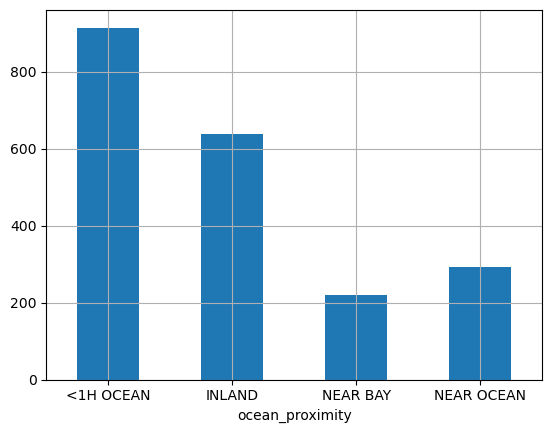

In [30]:
# in this example we are going to use stratified suffle split on ocean proximity,
# so that each are avialable in both train and test set instead of single set
import matplotlib.pyplot as plt 
test["ocean_proximity"].value_counts().sort_index().plot.bar(rot=0,grid=True)
# train["ocean_proximity"].value_counts().sort_index().plot.bar(rot=0,grid=True)

test["ocean_proximity"].value_counts()      # now island column not is in test set 
train["ocean_proximity"].value_counts()
# there is some problem create in the machine when we are train our machine 
# when we are train a machine with these data machine not able to indentify island area 

In [46]:
# uses of stratified suffle split 
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1,test_size=0.1,random_state=42)
for train_index,test_index in split.split(df,df["ocean_proximity"]):
    train_set=df.iloc[train_index]
    test_set=df.iloc[test_index]

# ISLAND test me nahi aane ka reason:

# 👉 dataset me bahut kam rows




# test_set["ocean_proximity"].value_counts()      # now island column not is in test set 
# train_set["ocean_proximity"].value_counts()
print(df["ocean_proximity"].value_counts(normalize=True))
print(train_set["ocean_proximity"].value_counts(normalize=True))
print(test_set["ocean_proximity"].value_counts(normalize=True))

ocean_proximity
<1H OCEAN     0.442636
INLAND        0.317393
NEAR OCEAN    0.128779
NEAR BAY      0.110950
ISLAND        0.000242
Name: proportion, dtype: float64
ocean_proximity
<1H OCEAN     0.442614
INLAND        0.317399
NEAR OCEAN    0.128768
NEAR BAY      0.110950
ISLAND        0.000269
Name: proportion, dtype: float64
ocean_proximity
<1H OCEAN     0.442829
INLAND        0.317345
NEAR OCEAN    0.128876
NEAR BAY      0.110950
Name: proportion, dtype: float64
